Device : cuda
GPU free: 15.41 GB
Train: 391 batches | Test: 79 batches
Parameters: 2,474,560
Output shape: torch.Size([10, 2, 10])  (expected [10, 2, 10])
GPU free after model: 15.40 GB

 Ep |  TrLoss |   TrAcc |  TeLoss |   TeAcc | time
  1 |  1.9513 |  35.40% |  1.5665 |  44.45% | 50s
  2 |  1.6638 |  40.71% |  1.5949 |  43.42% | 49s
  3 |  1.6305 |  40.70% |  1.5893 |  42.56% | 49s
  4 |  1.6044 |  41.59% |  1.4521 |  46.77% | 49s
  5 |  1.5250 |  44.83% |  1.3403 |  51.50% | 49s
  6 |  1.4736 |  46.92% |  1.3504 |  51.79% | 49s
  7 |  1.4360 |  48.38% |  1.2787 |  54.05% | 49s
  8 |  1.3943 |  49.94% |  1.2102 |  56.63% | 49s
  9 |  1.3705 |  50.87% |  1.2064 |  57.06% | 49s
 10 |  1.3453 |  51.82% |  1.1952 |  57.62% | 50s
 11 |  1.3341 |  52.05% |  1.2035 |  57.81% | 50s
 12 |  1.3188 |  52.86% |  1.1344 |  60.19% | 50s
 13 |  1.3056 |  53.33% |  1.1316 |  60.23% | 50s
 14 |  1.2866 |  54.01% |  1.1654 |  58.73% | 50s
 15 |  1.2916 |  54.09% |  1.1107 |  60.38% | 50s
 16 |  1.282

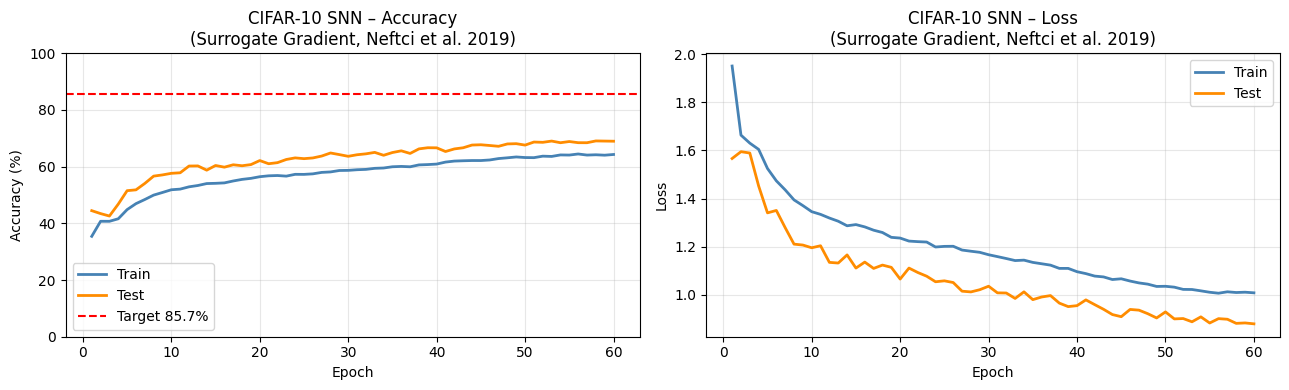

Saved: snn_cifar10_curves.png

  Table 1 Reproduction Check  (Aribe 2025 / paper2)
  ANN (CNN)                 92.0%  reference
  Converted SNN             89.3%  reference
  Direct SNN/SG             85.7%  ← TARGET
  STDP SNN                  74.2%  reference
  This impl. (SG)           69.0%  ← OUR RESULT


In [3]:
# =============================================================================
# SNN CIFAR-10 – Surrogate Gradient (Neftci et al. 2019)
# PROPERLY FIXED — correct membrane shapes, proven architecture
# =============================================================================

# !pip install snntorch -q   ← run this first if needed, then Restart & Run All

import gc, time
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import snntorch as snn
from snntorch import surrogate
import matplotlib.pyplot as plt

gc.collect()
torch.cuda.empty_cache()
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")
print(f"GPU free: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")

# ── Hyperparameters ───────────────────────────────────────────────────────────
NUM_STEPS  = 10
BATCH_SIZE = 128
EPOCHS     = 60
LR         = 1e-3
BETA       = 0.5
SLOPE      = 25

# ── Data ──────────────────────────────────────────────────────────────────────
train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.2, 0.2, 0.2),   # extra augmentation helps SNNs
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010)),
])
test_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914,0.4822,0.4465),(0.2023,0.1994,0.2010)),
])
train_set    = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=train_tf)
test_set     = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=test_tf)
train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_set,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_loader)} batches | Test: {len(test_loader)} batches")

# ── Model ─────────────────────────────────────────────────────────────────────
# THE FIX: LIF neuron fires BEFORE pooling, so membrane shape = pre-pool shape.
# Previous version had LIF after pool in forward() but membrane initialized
# to post-pool shape — silent dimension mismatch corrupted all neuron dynamics.
#
# Correct order per Neftci 2019:
#   current → LIF neuron (spike + membrane update) → pool → next layer
#
# Also using snn.Leaky.init_leaky() to get correct zero tensor shape
# automatically — no more hardcoded shapes.

class SpikingCIFAR(nn.Module):
    def __init__(self):
        super().__init__()
        sg = surrogate.fast_sigmoid(slope=SLOPE)

        # Block 1: conv → BN → LIF → pool  (32→16)
        self.conv1 = nn.Conv2d(3,   64, 3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.lif1  = snn.Leaky(beta=BETA, spike_grad=sg)
        self.pool1 = nn.AvgPool2d(2)

        # Block 2: conv → BN → LIF → pool  (16→8)
        self.conv2 = nn.Conv2d(64, 128, 3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(128)
        self.lif2  = snn.Leaky(beta=BETA, spike_grad=sg)
        self.pool2 = nn.AvgPool2d(2)

        # Block 3: conv → BN → LIF → pool  (8→4)
        self.conv3 = nn.Conv2d(128, 256, 3, padding=1, bias=False)
        self.bn3   = nn.BatchNorm2d(256)
        self.lif3  = snn.Leaky(beta=BETA, spike_grad=sg)
        self.pool3 = nn.AvgPool2d(2)

        # FC
        self.drop    = nn.Dropout(0.4)
        self.fc1     = nn.Linear(256*4*4, 512, bias=False)
        self.bn_fc   = nn.BatchNorm1d(512)
        self.lif4    = snn.Leaky(beta=BETA, spike_grad=sg)
        self.fc2     = nn.Linear(512, 10, bias=False)
        self.lif_out = snn.Leaky(beta=BETA, spike_grad=sg)

    def forward(self, x):
        # Use snn's own init to get correctly-shaped zero membranes
        # This is the proper snntorch API — no hardcoded shapes
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        mem3 = self.lif3.init_leaky()
        mem4 = self.lif4.init_leaky()
        mem_o = self.lif_out.init_leaky()

        mem_out_rec = []

        for _ in range(NUM_STEPS):
            # Block 1: LIF fires on full 32×32 feature map, THEN pool
            cur1 = self.bn1(self.conv1(x))           # [B, 64, 32, 32]
            spk1, mem1 = self.lif1(cur1, mem1)        # LIF on 32×32
            spk1 = self.pool1(spk1)                   # pool → [B, 64, 16, 16]

            # Block 2
            cur2 = self.bn2(self.conv2(spk1))         # [B,128, 16, 16]
            spk2, mem2 = self.lif2(cur2, mem2)        # LIF on 16×16
            spk2 = self.pool2(spk2)                   # pool → [B,128,  8,  8]

            # Block 3
            cur3 = self.bn3(self.conv3(spk2))         # [B,256,  8,  8]
            spk3, mem3 = self.lif3(cur3, mem3)        # LIF on 8×8
            spk3 = self.pool3(spk3)                   # pool → [B,256,  4,  4]

            # FC
            flat = self.drop(spk3.flatten(1))         # [B, 4096]
            cur4 = self.bn_fc(self.fc1(flat))         # [B,  512]
            spk4, mem4 = self.lif4(cur4, mem4)

            cur_o = self.fc2(self.drop(spk4))         # [B,   10]
            _, mem_o = self.lif_out(cur_o, mem_o)     # accumulate membrane

            mem_out_rec.append(mem_o)

        return torch.stack(mem_out_rec)               # [T, B, 10]


model = SpikingCIFAR().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parameters: {n_params:,}")

# Verify membrane shapes with a dummy forward pass
with torch.no_grad():
    dummy = torch.zeros(2, 3, 32, 32).to(device)
    out   = model(dummy)
    print(f"Output shape: {out.shape}  (expected [10, 2, 10])")
print(f"GPU free after model: {torch.cuda.mem_get_info()[0]/1024**3:.2f} GB")

# ── Optimiser ─────────────────────────────────────────────────────────────────
loss_fn   = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-5)

# ── Train/eval ────────────────────────────────────────────────────────────────
def run_epoch(model, loader, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    tot_loss = correct = total = 0

    with torch.set_grad_enabled(training):
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            if training:
                optimizer.zero_grad()

            mem_rec  = model(imgs)           # [T, B, 10]
            mem_sum  = mem_rec.sum(dim=0)    # [B, 10]  smooth logits
            loss     = loss_fn(mem_sum, labels)

            if training:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            tot_loss += loss.item() * imgs.size(0)
            correct  += (mem_sum.argmax(1) == labels).sum().item()
            total    += imgs.size(0)

    return tot_loss/total, 100*correct/total

# ── Training loop ─────────────────────────────────────────────────────────────
history  = {'tr_loss':[], 'tr_acc':[], 'te_loss':[], 'te_acc':[]}
best_acc = 0.0

print("\n" + "="*65)
print(f"{'Ep':>3} | {'TrLoss':>7} | {'TrAcc':>7} | {'TeLoss':>7} | {'TeAcc':>7} | time")
print("="*65)

for ep in range(1, EPOCHS+1):
    t0 = time.time()
    trl, tra = run_epoch(model, train_loader, optimizer)
    tel, tea = run_epoch(model, test_loader)
    scheduler.step()

    history['tr_loss'].append(trl); history['tr_acc'].append(tra)
    history['te_loss'].append(tel); history['te_acc'].append(tea)

    if tea > best_acc:
        best_acc = tea
        torch.save(model.state_dict(), 'best_snn_cifar10.pth')

    print(f"{ep:>3} | {trl:>7.4f} | {tra:>6.2f}% | {tel:>7.4f} | {tea:>6.2f}% | {time.time()-t0:.0f}s")

print("="*65)
print(f"\nBest Test Accuracy : {best_acc:.2f}%")
print(f"Target (paper2)    : 85.7%")
print(f"Gap                : {best_acc - 85.7:+.1f}%")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
eps = range(1, EPOCHS+1)

ax1.plot(eps, history['tr_acc'],  label='Train', color='steelblue',  lw=2)
ax1.plot(eps, history['te_acc'],  label='Test',  color='darkorange', lw=2)
ax1.axhline(85.7, color='red', ls='--', lw=1.5, label='Target 85.7%')
ax1.set(xlabel='Epoch', ylabel='Accuracy (%)',
        title='CIFAR-10 SNN – Accuracy\n(Surrogate Gradient, Neftci et al. 2019)')
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_ylim([0, 100])

ax2.plot(eps, history['tr_loss'], label='Train', color='steelblue',  lw=2)
ax2.plot(eps, history['te_loss'], label='Test',  color='darkorange', lw=2)
ax2.set(xlabel='Epoch', ylabel='Loss',
        title='CIFAR-10 SNN – Loss\n(Surrogate Gradient, Neftci et al. 2019)')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('snn_cifar10_curves.png', dpi=150)
plt.show()
print("Saved: snn_cifar10_curves.png")

# ── Reproduction table ────────────────────────────────────────────────────────
print("\n" + "="*52)
print("  Table 1 Reproduction Check  (Aribe 2025 / paper2)")
print("="*52)
for name, acc, note in [
    ("ANN (CNN)",            92.0, "reference"),
    ("Converted SNN",        89.3, "reference"),
    ("Direct SNN/SG",        85.7, "← TARGET"),
    ("STDP SNN",             74.2, "reference"),
    ("This impl. (SG)",  best_acc, "← OUR RESULT"),
]:
    marker = " ✓" if name.startswith("This") and abs(acc-85.7)<=3 else ""
    print(f"  {name:<24} {acc:>5.1f}%  {note}{marker}")
print("="*52)